In [64]:
import numpy as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from utils import set_pretty_prints, load_dataset

In [65]:
set_pretty_prints()

In [3]:
df = load_dataset('imobiliare.ro')

In [4]:
df

,Unnamed: 0,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price/Surface,Price,WebPage
0,1,2,56.00,0,1,0,2,1,1,639.29,35800,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAU700006?lista=2349706&listing=1
1,2,2,57.00,0,1,0,2,0,1,628.07,35800,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAG00001O?lista=2349706&listing=1
2,3,2,67.00,0,1,0,2,1,1,591.04,39600,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/rahova/apartament-de-vanzare-2-camere-XAG00001K?lista=2349706&listing=1
3,4,1,48.00,0,1,0,2,1,1,620.83,29800,https://www.imobiliare.ro/vanzare-garsoniere/bucuresti/rahova/garsoniera-de-vanzare-XAG00001J?lista=2349706&listing=1
4,5,3,89.60,0,0,1,3,1,1,1260.04,112900,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/p-ta-presei-libere/apartament-de-vanzare-3-camere-XB0V00003?lista=2349706&listing=1
...,...,...,...,...,...,...,...,...,...,...,...,...
9892,9894,4,90.00,0,0,1,8,0,0,944.44,85000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/crangasi/apartament-de-vanzare-4-camere-X5LL10023?lista=2349706&listing=1
9893,9895,3,85.00,0,0,1,8,1,0,1588.22,134999,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/central/apartament-de-vanzare-3-camere-X9I6100JP?lista=2349706&listing=1
9894,9896,2,48.00,0,0,1,4,0,0,1229.17,59000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/apusului/apartament-de-vanzare-2-camere-XBJG000HP?lista=2349706&listing=1
9895,9897,4,83.81,0,0,1,3,1,1,1312.49,110000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/theodor-pallady/penthouse-de-vanzare-4-camere-XANO10193?lista=2349706&listing=1


In [5]:
y_price = df["Price"]

X = df.iloc[:, 1:9]


In [6]:
y_price

0        35800
1        35800
2        39600
3        29800
4       112900
         ...  
9892     85000
9893    134999
9894     59000
9895    110000
9896     61500
Name: Price, Length: 9897, dtype: int64

In [7]:
X

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
0,2,56.00,0,1,0,2,1,1
1,2,57.00,0,1,0,2,0,1
2,2,67.00,0,1,0,2,1,1
3,1,48.00,0,1,0,2,1,1
4,3,89.60,0,0,1,3,1,1
...,...,...,...,...,...,...,...,...
9892,4,90.00,0,0,1,8,0,0
9893,3,85.00,0,0,1,8,1,0
9894,2,48.00,0,0,1,4,0,0
9895,4,83.81,0,0,1,3,1,1


# Exploration of data

In [8]:
def plot_feature_distrib(name, log=False):
    plt.figure(figsize=(8, 5))
    plt.hist(df[name], bins=30, color='skyblue', edgecolor='black', log=log)
    plt.title(f'Distribution of {name}')
    plt.xlabel(name)
    plt.grid()
    plt.show()

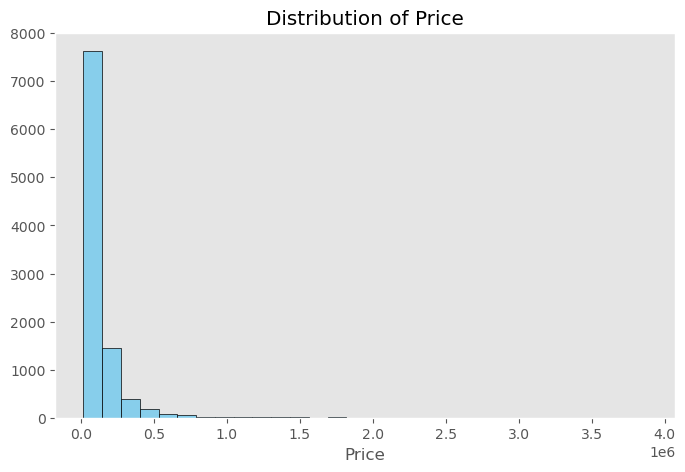

In [9]:
plot_feature_distrib("Price")


In [10]:
y_price.describe()


count    9.897000e+03
mean     1.349255e+05
std      1.781450e+05
min      1.800000e+04
25%      6.350000e+04
50%      8.715000e+04
75%      1.390000e+05
max      3.880000e+06
Name: Price, dtype: float64

In [11]:
df[df["Price"]>=3e6]

,Unnamed: 0,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price/Surface,Price,WebPage
1914,1915,5,350.00,0,0,1,6,1,0,8571.43,3000000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/herastrau/penthouse-de-vanzare-5-camere-X2F71004A?lista=2349706&listing=1
2947,2948,4,322.00,0,0,1,5,1,1,12049.69,3880000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/herastrau/penthouse-de-vanzare-4-camere-X9V60003Q?lista=2349706&listing=1
7755,7756,5,160.73,0,0,1,5,0,1,20531.33,3300000,https://www.imobiliare.ro/vanzare-apartamente/bucuresti/aviatorilor/apartament-de-vanzare-5-camere-X3RN001BK?lista=2349706&listing=1


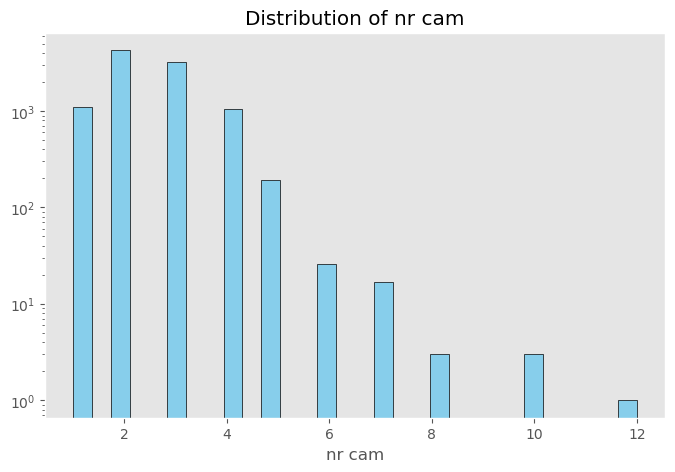

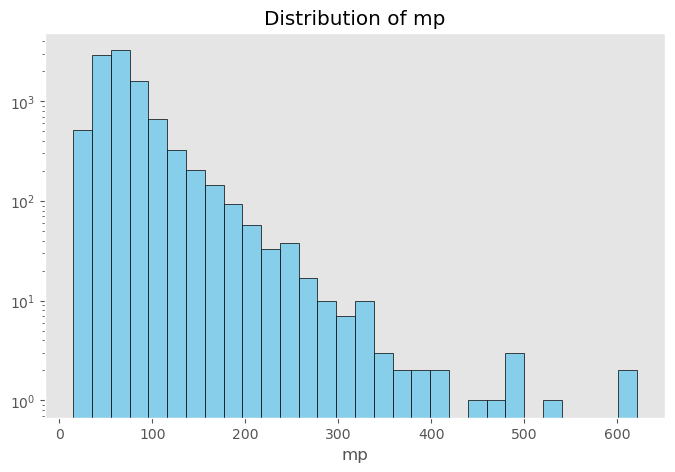

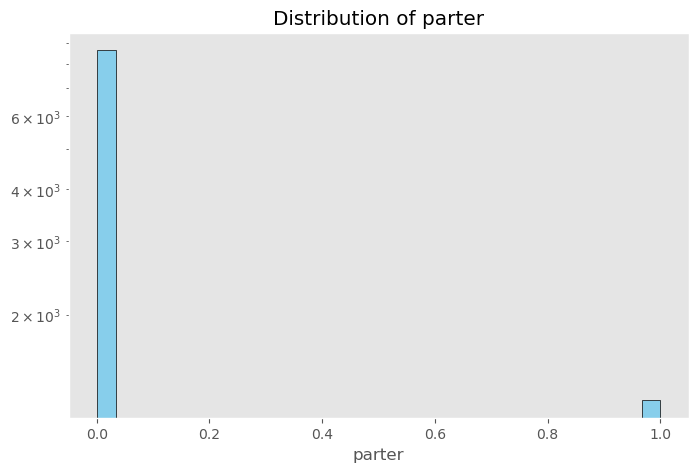

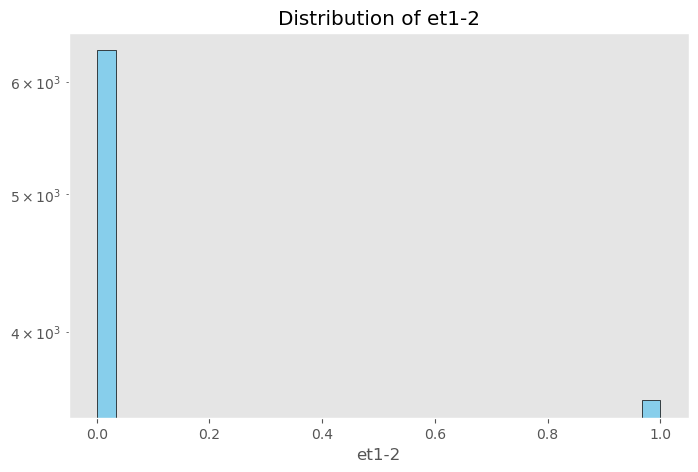

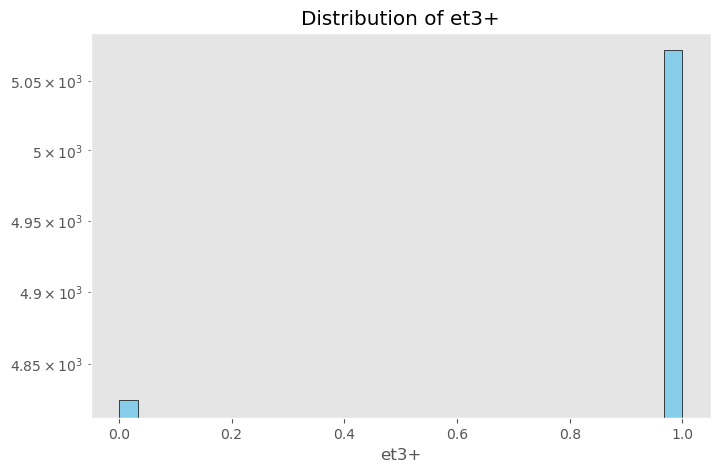

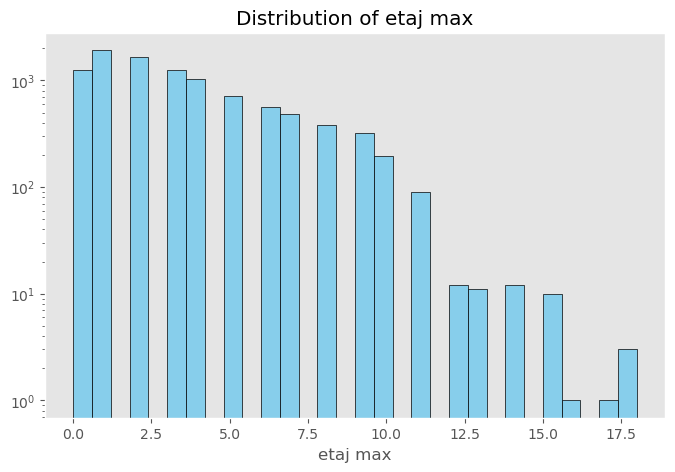

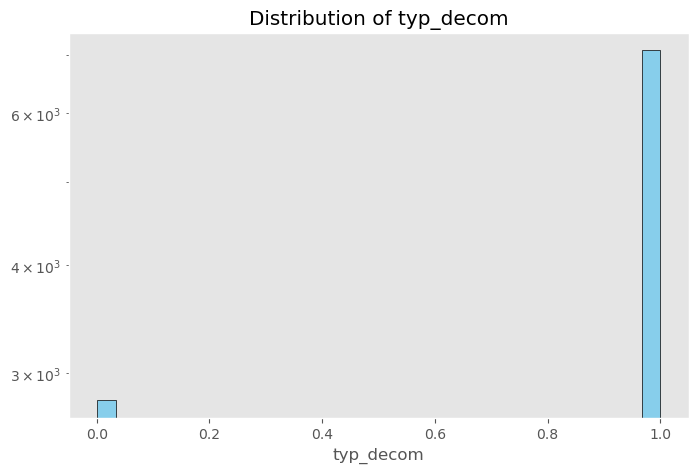

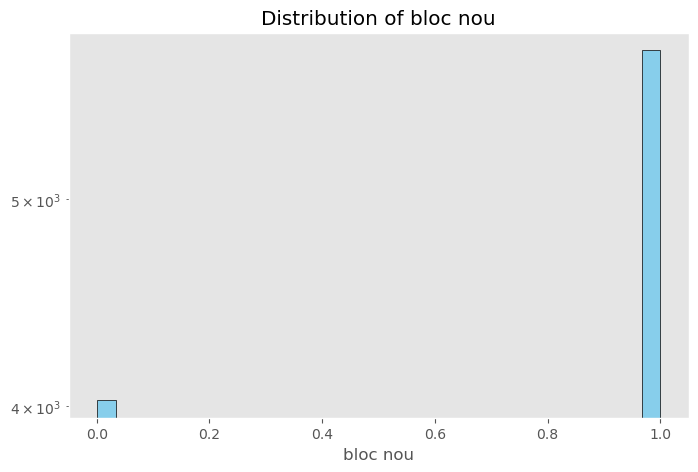

In [12]:
for col in X.columns:
    plot_feature_distrib(col, log=True)

In [13]:
X.corr()


,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
nr cam,1.000000,0.777186,0.003816,-0.067465,0.062328,0.073172,-0.000365,-0.139376
mp,0.777186,1.000000,0.000869,-0.056167,0.053421,0.065719,0.087754,0.006321
parter,0.003816,0.000869,1.000000,-0.285501,-0.388748,-0.448826,0.004277,-0.002453
et1-2,-0.067465,-0.056167,-0.285501,1.000000,-0.772008,-0.500485,0.065535,0.187789
et3+,0.062328,0.053421,-0.388748,-0.772008,1.000000,0.778814,-0.065839,-0.178905
etaj max,0.073172,0.065719,-0.448826,-0.500485,0.778814,1.000000,-0.071077,-0.193046
typ_decom,-0.000365,0.087754,0.004277,0.065535,-0.065839,-0.071077,1.000000,0.213843
bloc nou,-0.139376,0.006321,-0.002453,0.187789,-0.178905,-0.193046,0.213843,1.000000


In [14]:
df.columns

Index(['Unnamed: 0', 'nr cam', 'mp', 'parter', 'et1-2', 'et3+', 'etaj max', 'typ_decom', 'bloc nou', 'Price/Surface', 'Price', 'WebPage'], dtype='object')

In [15]:
selected_columns = ['nr cam', 'mp', 'parter', 'et1-2', 'et3+', 'etaj max', 'typ_decom', 'bloc nou', 'Price']
df[selected_columns].corr()

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou,Price
nr cam,1.000000,0.777186,0.003816,-0.067465,0.062328,0.073172,-0.000365,-0.139376,0.525333
mp,0.777186,1.000000,0.000869,-0.056167,0.053421,0.065719,0.087754,0.006321,0.770386
parter,0.003816,0.000869,1.000000,-0.285501,-0.388748,-0.448826,0.004277,-0.002453,-0.020806
et1-2,-0.067465,-0.056167,-0.285501,1.000000,-0.772008,-0.500485,0.065535,0.187789,-0.061217
et3+,0.062328,0.053421,-0.388748,-0.772008,1.000000,0.778814,-0.065839,-0.178905,0.072650
etaj max,0.073172,0.065719,-0.448826,-0.500485,0.778814,1.000000,-0.071077,-0.193046,0.091064
typ_decom,-0.000365,0.087754,0.004277,0.065535,-0.065839,-0.071077,1.000000,0.213843,0.034928
bloc nou,-0.139376,0.006321,-0.002453,0.187789,-0.178905,-0.193046,0.213843,1.000000,0.035021
Price,0.525333,0.770386,-0.020806,-0.061217,0.072650,0.091064,0.034928,0.035021,1.000000


## TODO: 

Create a "one-hot" predictor based on the "zone" feature extracted from the URL then re-compute the correlation matrix determining which zones are more expensive than others.

# Modeling

## Start with a simple linear regression model

Naively we aim to solve `X * w  + b = y` => w = ? 
X_bias  <- [X | 1]
=> Normal equation `w = (X^T*X)^(-1) * X^T *y`

X = m lines x n features = [M, N]
y = [M, 1]

X^TX = [N, M] * [M, N] = [N, N] => square matrix => inverted => [N, N]
[N, N] * [N, M] = [N, M]
[N, M] * [M, 1] = [N, 1] => w

Final reqularization step:
w = (X^T*X + λI)^(-1) * X^T *y


## Next steps:
### Continue with simple neural graph model
#### Enhance the model via grid search

In [66]:
def test_linear_model(X, y, weights, y_scale=None):
    # pd.set_option('display.float_format', '{:.3f}'.format)
    y_pred = X.dot(weights)
    if y_scale is not None:
      y_min, y_max = y_scale
      y_pred = y_pred * (y_max - y_min) + y_min # reverse of y_min_max_normed = (y - y_min) / (y_max - y_min)
      y = y * (y_max - y_min) + y_min 
    residuals = y - y_pred
    err_prc = np.abs(residuals) / y
    mse = (residuals ** 2).mean()
    df_test = pd.DataFrame({'Actual': y, 'Predicted': y_pred, 'Residuals': residuals, 'ErrPrc': err_prc * 100})
    print(df_test.head(10))
    print(df_test.tail(10))
    print(f'Mean Squared Error: {mse}')
    print(f"Mean percentual error: {err_prc.mean() * 100:.3f}%")
    return mse

In [30]:
np_X = X.values
np_X

array([[  2.  ,  56.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  2.  ,  57.  ,   0.  ,   1.  ,   0.  ,   2.  ,   0.  ,   1.  ],
       [  2.  ,  67.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  1.  ,  48.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  3.  ,  89.6 ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   4.  ,   1.  ,   1.  ],
       [  6.  , 334.  ,   0.  ,   0.  ,   1.  ,  10.  ,   1.  ,   1.  ],
       [  3.  , 104.26,   0.  ,   0.  ,   1.  ,  11.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  1.  ,  43.02,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   1.  ],
       [  3.  ,  80.23,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ],
       [  1.  ,  30.  ,   1.  ,   0.  ,   0.  ,   0

In [31]:
np_X_b = np.concatenate([np_X, np.ones((np_X.shape[0], 1))], axis=1)
np_X_b

array([[  2.  ,  56.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  57.  ,   0.  ,   1.  ,   0.  ,   2.  ,   0.  ,   1.  ,   1.  ],
       [  2.  ,  67.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  1.  ,  48.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  3.  ,  89.6 ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   2.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   4.  ,   1.  ,   1.  ,   1.  ],
       [  6.  , 334.  ,   0.  ,   0.  ,   1.  ,  10.  ,   1.  ,   1.  ,   1.  ],
       [  3.  , 104.26,   0.  ,   0.  ,   1.  ,  11.  ,   1.  ,   1.  ,   1.  ],
       [  2.  ,  65.  ,   0.  ,   1.  ,   0.  ,   1.  ,   0.  ,   1.  ,   1.  ],
       [  2.  ,  46.  ,   0.  ,   0.  ,   1.  ,   3.  ,   1.  ,   1.  ,   1.  ],
       [  1.  ,  43.02,   1.  ,   0.  ,   0.  ,   0.  ,   1.  ,   1.  ,   1.  ],
       [  3.  ,  80.23,   0.

In [32]:
np_w1 = np.linalg.pinv(np_X_b.T.dot(np_X_b)).dot(np_X_b.T).dot(y_price)
np_w1


array([-35253.17,   4068.76, -19653.11, -19536.64, -18810.11,   2762.81, -18637.49,   7934.74, -57999.86])

In [33]:
test_linear_model(np_X_b, y_price, np_w1)

    Actual     Predicted     Residuals      ErrPrc
0    35800  7.463073e+04 -3.883073e+04  108.465717
1    35800  9.733697e+04 -6.153697e+04  171.890991
2    39600  1.193871e+05 -7.978711e+04  201.482605
3    29800  7.733379e+04 -4.753379e+04  159.509376
4   112900  1.795773e+05 -6.667732e+04   59.058741
5    37400  1.112496e+05 -7.384959e+04  197.458789
6    39500  4.019526e+04 -6.952581e+02    1.760147
7  2350000  1.087563e+06  1.262437e+06   53.720724
8   332000  2.613279e+05  7.067215e+04   21.286792
9    39900  1.271243e+05 -8.722426e+04  218.607176
      Actual      Predicted     Residuals      ErrPrc
9887   47000   43077.370160   3922.629840    8.346021
9888   34500  -28458.867164  62958.867164  182.489470
9889   56000   28301.022572  27698.977428   49.462460
9890  101000  139730.923152 -38730.923152   38.347449
9891   79524   88871.394641  -9347.394641   11.754181
9892   85000  170468.449821 -85468.449821  100.551117
9893  134999  166740.318014 -31741.318014   23.512262
9894   

12333288996.96286

In [34]:
X.describe()

,nr cam,mp,parter,et1-2,et3+,etaj max,typ_decom,bloc nou
count,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.000000,9897.00000
mean,2.505709,73.704865,0.125695,0.361827,0.512479,3.336466,0.717591,0.59321
std,0.950467,40.174869,0.331522,0.480553,0.499870,2.818757,0.450194,0.49126
min,1.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,51.800000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
50%,2.000000,64.000000,0.000000,0.000000,1.000000,3.000000,1.000000,1.00000
75%,3.000000,83.000000,0.000000,1.000000,1.000000,5.000000,1.000000,1.00000
max,12.000000,621.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.00000


In [35]:
np_X_n = (np_X - np.mean(np_X, axis=0)) / np.std(np_X, axis=0)
np_X_b_n = np.concatenate([np_X_n, np.ones((np_X_n.shape[0], 1))], axis=1)
np_X_b_n

array([[-0.53, -0.44, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-0.53, -0.42, -0.38,  1.33, -1.03, -0.47, -1.59,  0.83,  1.  ],
       [-0.53, -0.17, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-1.58, -0.64, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [ 0.52,  0.4 , -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-0.53, -0.22, -0.38,  1.33, -1.03, -0.47,  0.63,  0.83,  1.  ],
       [-0.53, -0.69, -0.38, -0.75,  0.98,  0.24,  0.63,  0.83,  1.  ],
       [ 3.68,  6.48, -0.38, -0.75,  0.98,  2.36,  0.63,  0.83,  1.  ],
       [ 0.52,  0.76, -0.38, -0.75,  0.98,  2.72,  0.63,  0.83,  1.  ],
       [-0.53, -0.22, -0.38,  1.33, -1.03, -0.83, -1.59,  0.83,  1.  ],
       [-0.53, -0.69, -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-1.58, -0.76,  2.64, -0.75, -1.03, -1.18,  0.63,  0.83,  1.  ],
       [ 0.52,  0.16, -0.38, -0.75,  0.98, -0.12,  0.63,  0.83,  1.  ],
       [-1.58, -1.09,  2.64, -0.75, -1.03, -1.18,  0.63,  0.83, 

In [36]:
np_w2 = np.linalg.pinv(np_X_b_n.T.dot(np_X_b_n)).dot(np_X_b_n.T).dot(y_price)
np_w2

array([-33505.29, 163453.73,   2879.18,   3496.39,   4061.08,   7787.29,  -8390.06,   3897.82, 134925.49])

In [37]:
test_linear_model(np_X_b_n, y_price, np_w2)

    Actual     Predicted     Residuals      ErrPrc
0    35800  7.437643e+04 -3.857643e+04  107.755398
1    35800  9.708268e+04 -6.128268e+04  171.180673
2    39600  1.191328e+05 -7.953282e+04  200.840449
3    29800  7.707950e+04 -4.727950e+04  158.656040
4   112900  1.794451e+05 -6.654507e+04   58.941602
5    37400  1.109953e+05 -7.359529e+04  196.778859
6    39500  4.006301e+04 -5.630082e+02    1.425337
7  2350000  1.087431e+06  1.262569e+06   53.726351
8   332000  2.611956e+05  7.080440e+04   21.326626
9    39900  1.268700e+05 -8.696997e+04  217.969848
      Actual      Predicted     Residuals      ErrPrc
9887   47000   42823.076157   4176.923843    8.887072
9888   34500  -27187.646693  61687.646693  178.804773
9889   56000   29572.243043  26427.756957   47.192423
9890  101000  139476.629148 -38476.629148   38.095672
9891   79524   88617.100638  -9093.100638   11.434411
9892   85000  170336.199931 -85336.199931  100.395529
9893  134999  166608.068124 -31609.068124   23.414298
9894   

12333524480.668766

## 2025-12-08

In [38]:
np_y_n = (y_price - y_price.min()) / (y_price.max() - y_price.min())
print(np_y_n.min(), np_y_n.max(), np_y_n.mean())

0.0 1.0 0.030275890690162528


In [39]:
np_w3 = np.linalg.pinv(np_X_b_n.T.dot(np_X_b_n)).dot(np_X_b_n.T).dot(np_y_n)
np_w3

array([-0.01,  0.04,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.03])

In [40]:
test_linear_model(np_X_b_n, np_y_n, np_w3, y_scale=(y_price.min(), y_price.max()))

      Actual     Predicted     Residuals      ErrPrc
0    35800.0  7.442508e+04 -3.862508e+04  107.891283
1    35800.0  9.713133e+04 -6.133133e+04  171.316557
2    39600.0  1.191815e+05 -7.958146e+04  200.963294
3    29800.0  7.712815e+04 -4.732815e+04  158.819284
4   112900.0  1.794462e+05 -6.654615e+04   58.942560
5    37400.0  1.110439e+05 -7.364394e+04  196.908930
6    39500.0  4.006409e+04 -5.640901e+02    1.428076
7  2350000.0  1.087432e+06  1.262568e+06   53.726305
8   332000.0  2.611967e+05  7.080332e+04   21.326300
9    39900.0  1.269186e+05 -8.701862e+04  218.091769
        Actual      Predicted     Residuals      ErrPrc
9887   47000.0   42871.722795   4128.277205    8.783569
9888   34500.0  -27332.092626  61832.092626  179.223457
9889   56000.0   29427.797110  26572.202890   47.450362
9890  101000.0  139525.275787 -38525.275787   38.143837
9891   79524.0   88665.747277  -9141.747277   11.495583
9892   85000.0  170337.281779 -85337.281779  100.396802
9893  134999.0  166609.14

12333472700.699427

In [41]:
np_w4 = np.linalg.inv(np_X_b_n.T.dot(np_X_b_n) + 0.1 * np.eye(np_X_n.shape[1] + 1)).dot(np_X_b_n.T).dot(np_y_n)
np_w4

array([-0.01,  0.04, -0.  , -0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.03])

In [42]:
test_linear_model(np_X_b_n, np_y_n, np_w4, y_scale=(y_price.min(), y_price.max()))

      Actual     Predicted     Residuals      ErrPrc
0    35800.0  7.463001e+04 -3.883001e+04  108.463711
1    35800.0  9.733518e+04 -6.153518e+04  171.885983
2    39600.0  1.193850e+05 -7.978500e+04  201.477276
3    29800.0  7.732950e+04 -4.752950e+04  159.494981
4   112900.0  1.795773e+05 -6.667726e+04   59.058689
5    37400.0  1.112477e+05 -7.384773e+04  197.453823
6    39500.0  4.019612e+04 -6.961157e+02    1.762318
7  2350000.0  1.087546e+06  1.262454e+06   53.721463
8   332000.0  2.613258e+05  7.067421e+04   21.287412
9    39900.0  1.271215e+05 -8.722148e+04  218.600190
        Actual      Predicted     Residuals      ErrPrc
9887   47000.0   43073.777525   3926.222475    8.353665
9888   34500.0  -28457.743980  62957.743980  182.486214
9889   56000.0   28301.705900  27698.294100   49.461239
9890  101000.0  139728.179995 -38728.179995   38.344733
9891   79524.0   88870.233458  -9346.233458   11.752721
9892   85000.0  170470.808022 -85470.808022  100.553892
9893  134999.0  166739.67

12333289008.248774

# Conclusions so far

- with all the bells and whistles we can reach a better error than 40% (mean absolute percentage error)
- we need now to squeeze as much salient features as possible from the data

In [43]:
df['Location'] = df["WebPage"].apply(lambda x: x.split('/')[5])
df['Location']

0                   rahova
1                   rahova
2                   rahova
3                   rahova
4       p-ta-presei-libere
               ...        
9892              crangasi
9893               central
9894              apusului
9895       theodor-pallady
9896           politehnica
Name: Location, Length: 9897, dtype: object

In [44]:
df_new = pd.get_dummies(df['Location'], prefix="L", columns=['Location'], dtype=np.uint8)
df_new


,L_1-decembrie-1918,L_1-mai,L_13-septembrie,L_16-februarie,L_agronomie,L_alba-iulia,L_alexandriei,L_alexandru-obregia,L_andronache,L_antiaeriana,L_aparatorii-patriei,L_apusului,L_arcul-de-triumf,L_armeneasca,L_aviatiei,L_aviatorilor,L_baba-novac,L_baicului,L_balta-alba,L_baneasa,L_banu-manta,L_barbu-vacarescu,L_basarab,L_basarabia,L_batistei,L_bd-gloriei,L_beller,L_berceni,L_brancoveanu,L_bucur-obor,L_bucurestii-noi,L_calea-calarasilor,L_calea-plevnei,L_calea-victoriei,L_camil-ressu,L_campia-libertatii,L_cantemir,L_capitale,L_casin,L_central,L_centrul-civic,L_centrul-istoric,L_chibrit,L_chisinau,L_chitila,L_cismigiu,L_clabucet,L_clucerului,L_colentina,L_compozitorilor,L_constructorilor,L_cosbuc,L_costin-georgian,L_cotroceni,L_crangasi,L_dacia,L_damaroaia,L_decebal,L_doamna-ghica,L_domenii,L_dorobanti,L_dristor,L_drumul-gazarului,L_drumul-sarii,L_drumul-taberei,L_dudesti,L_eminescu,L_eroii-revolutiei,L_ferdinand,L_ferentari,L_fizicienilor,L_floreasca,L_foisorul-de-foc,L_fundeni,L_gara-de-nord,L_ghencea,L_giulesti,L_giurgiului,L_gorjului,L_gradina-icoanei,L_grivita,L_grozavesti,L_herastrau,L_iancu-nicolae,L_iancului,L_jiului,L_kiseleff,L_kogalniceanu,L_lacul-morii,L_lacul-tei,L_lahovari,L_libertatii,L_liviu-rebreanu,L_lucretiu-patrascanu,L_lujerului,L_macaralei,L_magheru,L_marasesti,L_margeanului,L_matei-voievod,L_metalurgiei,L_mihai-bravu,L_militari,L_morarilor,L_mosilor,L_muncii,L_natiunile-unite,L_nerva-traian,L_nicolae-grigorescu,L_nord,L_nordului,L_obor,L_octavian-goga,L_oltenitei,L_ozana,L_p-ta-alba-iulia,L_p-ta-amzei,L_p-ta-dorobanti,L_p-ta-gorjului,L_p-ta-muncii,L_p-ta-presei-libere,L_p-ta-resita,L_p-ta-romana,L_p-ta-rosetti,L_p-ta-sfanta-vineri,L_p-ta-unirii,L_p-ta-universitatii,L_p-ta-victoriei,L_pache-protopopescu,L_pacii,L_pajura,L_panduri,L_pantelimon,L_parcul-carol,L_parcul-circului,L_pipera,L_plevnei,L_politehnica,L_polona,L_prelungirea-ghencea,L_primaverii,L_progresul,L_rahova,L_regie,L_regina-elisabeta,L_romana,L_rosetti,L_sala-palatului,L_salaj,L_salajan,L_sebastian,L_serban-voda,L_sisesti,L_socului,L_soseaua-nordului,L_splaiul-independentei,L_splaiul-unirii,L_stefan-cel-mare,L_stirbei-voda,L_straulesti,L_sud,L_sud-est,L_tei,L_teiul-doamnei,L_televiziune,L_theodor-pallady,L_timisoara,L_timpuri-noi,L_tineretului,L_titan,L_titulescu,L_trafic-greu,L_turda,L_ultracentral,L_unirii,L_universitate,L_uverturii,L_vacaresti,L_valea-ialomitei,L_valea-oltului,L_vatra-luminoasa,L_veteranilor,L_victoriei,L_viilor,L_virtutii,L_vitan,L_vitan-barzesti,L_vitan-mall,L_vitanul-nou,L_zetarilor
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [45]:
np_loc = df_new.values
np_X_n_l = np.concatenate((np_X_n, np_loc), axis=1)
np_X_n_l.shape

(9897, 198)

In [46]:
np_X_n_l_b = np.concatenate((np_X_n_l, np.ones((np_X_n.shape[0], 1))), axis=1)
np_X_n_l_b.shape

(9897, 199)

# TODO:
  - check the correlation matrix now using `df_loc` + `Price` column`
  - recalculate the weights of a linear regression and check the error

# 2025-12-15

Now lets create the correlation matrix using the one-hot encoded zones

In [47]:
df_new["Price"] = df.Price
df_new.corr()

,L_1-decembrie-1918,L_1-mai,L_13-septembrie,L_16-februarie,L_agronomie,L_alba-iulia,L_alexandriei,L_alexandru-obregia,L_andronache,L_antiaeriana,L_aparatorii-patriei,L_apusului,L_arcul-de-triumf,L_armeneasca,L_aviatiei,L_aviatorilor,L_baba-novac,L_baicului,L_balta-alba,L_baneasa,L_banu-manta,L_barbu-vacarescu,L_basarab,L_basarabia,L_batistei,L_bd-gloriei,L_beller,L_berceni,L_brancoveanu,L_bucur-obor,L_bucurestii-noi,L_calea-calarasilor,L_calea-plevnei,L_calea-victoriei,L_camil-ressu,L_campia-libertatii,L_cantemir,L_capitale,L_casin,L_central,L_centrul-civic,L_centrul-istoric,L_chibrit,L_chisinau,L_chitila,L_cismigiu,L_clabucet,L_clucerului,L_colentina,L_compozitorilor,L_constructorilor,L_cosbuc,L_costin-georgian,L_cotroceni,L_crangasi,L_dacia,L_damaroaia,L_decebal,L_doamna-ghica,L_domenii,L_dorobanti,L_dristor,L_drumul-gazarului,L_drumul-sarii,L_drumul-taberei,L_dudesti,L_eminescu,L_eroii-revolutiei,L_ferdinand,L_ferentari,L_fizicienilor,L_floreasca,L_foisorul-de-foc,L_fundeni,L_gara-de-nord,L_ghencea,L_giulesti,L_giurgiului,L_gorjului,L_gradina-icoanei,L_grivita,L_grozavesti,L_herastrau,L_iancu-nicolae,L_iancului,L_jiului,L_kiseleff,L_kogalniceanu,L_lacul-morii,L_lacul-tei,L_lahovari,L_libertatii,L_liviu-rebreanu,L_lucretiu-patrascanu,L_lujerului,L_macaralei,L_magheru,L_marasesti,L_margeanului,L_matei-voievod,L_metalurgiei,L_mihai-bravu,L_militari,L_morarilor,L_mosilor,L_muncii,L_natiunile-unite,L_nerva-traian,L_nicolae-grigorescu,L_nord,L_nordului,L_obor,L_octavian-goga,L_oltenitei,L_ozana,L_p-ta-alba-iulia,L_p-ta-amzei,L_p-ta-dorobanti,L_p-ta-gorjului,L_p-ta-muncii,L_p-ta-presei-libere,L_p-ta-resita,L_p-ta-romana,L_p-ta-rosetti,L_p-ta-sfanta-vineri,L_p-ta-unirii,L_p-ta-universitatii,L_p-ta-victoriei,L_pache-protopopescu,L_pacii,L_pajura,L_panduri,L_pantelimon,L_parcul-carol,L_parcul-circului,L_pipera,L_plevnei,L_politehnica,L_polona,L_prelungirea-ghencea,L_primaverii,L_progresul,L_rahova,L_regie,L_regina-elisabeta,L_romana,L_rosetti,L_sala-palatului,L_salaj,L_salajan,L_sebastian,L_serban-voda,L_sisesti,L_socului,L_soseaua-nordului,L_splaiul-independentei,L_splaiul-unirii,L_stefan-cel-mare,L_stirbei-voda,L_straulesti,L_sud,L_sud-est,L_tei,L_teiul-doamnei,L_televiziune,L_theodor-pallady,L_timisoara,L_timpuri-noi,L_tineretului,L_titan,L_titulescu,L_trafic-greu,L_turda,L_ultracentral,L_unirii,L_universitate,L_uverturii,L_vacaresti,L_valea-ialomitei,L_valea-oltului,L_vatra-luminoasa,L_veteranilor,L_victoriei,L_viilor,L_virtutii,L_vitan,L_vitan-barzesti,L_vitan-mall,L_vitanul-nou,L_zetarilor,Price
L_1-decembrie-1918,1.000000,-0.015914,-0.017742,-0.001783,-0.002522,-0.005918,-0.006677,-0.006912,-0.001783,-0.004720,-0.022597,-0.006434,-0.007359,-0.009618,-0.031636,-0.011159,-0.012514,-0.002522,-0.001783,-0.032430,-0.009450,-0.020468,-0.002522,-0.012642,-0.003989,-0.001783,-0.004720,-0.041990,-0.028501,-0.008374,-0.023454,-0.017279,-0.003989,-0.009450,-0.005642,-0.004720,-0.006912,-0.007139,-0.003089,-0.008562,-0.002522,-0.002522,-0.003089,-0.007359,-0.003567,-0.012894,-0.001783,-0.002522,-0.018104,-0.002522,-0.002522,-0.001783,-0.006181,-0.011719,-0.015710,-0.014536,-0.010569,-0.015607,-0.010719,-0.018371,-0.021859,-0.024009,-0.002522,-0.006434,-0.035061,-0.003567,-0.010262,-0.007359,-0.008928,-0.002522,-0.002522,-0.024687,-0.005046,-0.013018,-0.007573,-0.010262,-0.008928,-0.010719,-0.015081,-0.008562,-0.009105,-0.014200,-0.037115,-0.014313,-0.020065,-0.003567,-0.012255,-0.005352,-0.005046,-0.010262,-0.001783,-0.003089,-0.006181,-0.002522,-0.018547,-0.001783,-0.005642,-0.003567,-0.003567,-0.002522,-0.014973,-0.018283,-0.041481,-0.004720,-0.016610,-0.005918,-0.004720,-0.015812,-0.014973,-0.007359,-0.010262,-0.012255,-0.005352,-0.010262,-0.006912,-0.008562,-0.001783,-0.003089,-0.003567,-0.008562,-0.008181,-0.001783,-0.006677,-0.004370,-0.001783,-0.008562,-0.003089,-0.011014,-0.007359,-0.011443,-0.007573,-0.007573,-0.021019,-0.013018,-0.005352,-0.036410,-0.003089,-0.010104,-0.007359,-0.021405,-0.014425,-0.002522,-0.020785,-0.006677,-0

In [49]:
np_w5 = np.linalg.inv(np_X_n_l_b.T.dot(np_X_n_l_b) + 0.1 * np.eye(np_X_n_l.shape[1] + 1)).dot(np_X_n_l_b.T).dot(np_y_n)
np_w5

array([-0.01,  0.03,  0.  ,  0.  , -0.  ,  0.  , -0.  ,  0.  , -0.01,  0.01, -0.  , -0.02,  0.01,  0.  , -0.02, -0.  , -0.  , -0.01, -0.01, -0.  ,  0.02, -0.02,  0.01,  0.07, -0.  , -0.01, -0.03, -0.  ,  0.  ,  0.  , -0.01, -0.  ,  0.  , -0.04,  0.01, -0.01, -0.01,  0.  , -0.01, -0.  , -0.01,  0.01,  0.  , -0.  , -0.  ,  0.04,  0.03,  0.  ,  0.01,  0.  ,  0.  , -0.  , -0.  ,  0.  , -0.01, -0.  , -0.01, -0.01, -0.  , -0.04,  0.  , -0.  , -0.  , -0.  , -0.01, -0.  , -0.01,  0.01,  0.01, -0.  ,
        0.  , -0.  , -0.01, -0.02,  0.  , -0.  , -0.01, -0.  , -0.  ,  0.02, -0.02, -0.01, -0.  , -0.01, -0.01, -0.01, -0.  ,  0.01,  0.  , -0.  ,  0.04, -0.  , -0.  , -0.01,  0.07, -0.  , -0.01, -0.  , -0.01,  0.01, -0.  , -0.  , -0.  ,  0.  ,  0.  , -0.02, -0.01,  0.  , -0.01, -0.  , -0.01, -0.01, -0.  ,  0.  ,  0.01, -0.  , -0.  , -0.  ,  0.05,  0.  ,  0.01, -0.01, -0.01,  0.  ,  0.  ,  0.02, -0.  , -0.  , -0.  , -0.  ,  0.  , -0.01, -0.03,  0.01,  0.01,  0.02, -0.  , -0.  , -0.01,  0.  ,
      

In [67]:
test_linear_model(np_X_n_l_b, np_y_n, np_w5, y_scale=(y_price.min(), y_price.max()))

       Actual   Predicted   Residuals  ErrPrc
0   35800.000   60526.793  -24726.793  69.069
1   35800.000   75970.686  -40170.686 112.209
2   39600.000   96449.297  -56849.297 143.559
3   29800.000   61112.645  -31312.645 105.076
4  112900.000  165151.769  -52251.769  46.281
5   37400.000   96417.307  -59017.307 157.800
6   39500.000   39773.447    -273.447   0.692
7 2350000.000 1058967.207 1291032.793  54.938
8  332000.000  271834.005   60165.995  18.122
9   39900.000  105055.587  -65155.587 163.297
         Actual  Predicted  Residuals  ErrPrc
9887  47000.000  37888.733   9111.267  19.386
9888  34500.000  21968.106  12531.894  36.324
9889  56000.000  12641.457  43358.543  77.426
9890 101000.000 111429.344 -10429.344  10.326
9891  79524.000  83966.773  -4442.773   5.587
9892  85000.000 139667.811 -54667.811  64.315
9893 134999.000 170996.997 -35997.997  26.665
9894  59000.000  55777.738   3222.262   5.461
9895 110000.000  89151.852  20848.148  18.953
9896  61500.000  48733.482  12766.

9114355173.140272

In [68]:
test_linear_model(np_X_b_n, np_y_n, np_w4, y_scale=(y_price.min(), y_price.max()))

       Actual   Predicted   Residuals  ErrPrc
0   35800.000   74630.008  -38830.008 108.464
1   35800.000   97335.182  -61535.182 171.886
2   39600.000  119385.001  -79785.001 201.477
3   29800.000   77329.504  -47529.504 159.495
4  112900.000  179577.260  -66677.260  59.059
5   37400.000  111247.730  -73847.730 197.454
6   39500.000   40196.116    -696.116   1.762
7 2350000.000 1087545.628 1262454.372  53.721
8  332000.000  261325.794   70674.206  21.287
9   39900.000  127121.476  -87221.476 218.600
         Actual  Predicted  Residuals  ErrPrc
9887  47000.000  43073.778   3926.222   8.354
9888  34500.000 -28457.744  62957.744 182.486
9889  56000.000  28301.706  27698.294  49.461
9890 101000.000 139728.180 -38728.180  38.345
9891  79524.000  88870.233  -9346.233  11.753
9892  85000.000 170470.808 -85470.808 100.554
9893 134999.000 166739.673 -31740.673  23.512
9894  59000.000  59034.104    -34.104   0.058
9895 110000.000 120771.278 -10771.278   9.792
9896  61500.000  30689.704  30810.

12333289008.248774

# Now for a real life approach

We split the data in train and test sets

In [69]:
# split the data in train and test sets
from sklearn.model_selection import train_test_split

np_X_n_l_b_train, np_X_n_l_b_test, np_y_n_train, np_y_n_test = train_test_split(
    np_X_n_l_b, np_y_n, test_size=0.2, random_state=42
)

# "train" the model with normal equation
np_w6 = np.linalg.inv(np_X_n_l_b_train.T.dot(np_X_n_l_b_train) + 0.1 * np.eye(np_X_n_l_b_train.shape[1])).dot(np_X_n_l_b_train.T).dot(np_y_n_train)

# evaluate the model on the train set
print("Train set evaluation:")
test_linear_model(np_X_n_l_b_train, np_y_n_train, np_w6, y_scale=(y_price.min(), y_price.max()))

# evaluate the model on the test set
print("\nTest set evaluation:")
test_linear_model(np_X_n_l_b_test, np_y_n_test, np_w6, y_scale=(y_price.min(), y_price.max()))

Train set evaluation:
         Actual  Predicted  Residuals  ErrPrc
1665 179000.000 144520.939  34479.061  19.262
1416  53500.000  64794.633 -11294.633  21.111
4147  53900.000  35148.566  18751.434  34.789
6473  75000.000  89354.584 -14354.584  19.139
6189 200000.000 134485.696  65514.304  32.757
3704 112000.000 149811.796 -37811.796  33.761
742  139999.000 177984.790 -37985.790  27.133
9255  48000.000  32721.720  15278.280  31.830
3620 133000.000 122802.528  10197.472   7.667
3826  79900.000  70433.102   9466.898  11.848
         Actual  Predicted  Residuals  ErrPrc
8322  46000.000  24176.108  21823.892  47.443
5578  57500.000  91886.773 -34386.773  59.803
4426  53520.000  32377.526  21142.474  39.504
466   92000.000  67347.109  24652.891  26.797
6265  98800.000 118885.273 -20085.273  20.329
5734 129500.000 204917.297 -75417.297  58.237
5191  97000.000 124167.288 -27167.288  28.008
5390  95000.000  46526.372  48473.628  51.025
860  119999.000  81563.322  38435.678  32.030
7270 119900.

8492109859.100802

## However...

This is not the way to do it in real life as in real life we do not have access to future data (test set) when training the model. So the right way to do it is to get the statistics from the training set and apply them to both training and test sets.

## TODO:
 Implement the above correctly and re-evaluate the linear model:
 1. split the RAW data in train and tests sets (un-normalized)
 2. compute the statistics (mean/std for X; min/max for Y) from the TRAIN set only
 3. normalize the train data
 4. compute the weights using the normalized train data
 5. Now simulate production environment where you apply the already known statistics in the process of normalizing the TEST set

# Now lets move on to  a simple neural model !

We are going to use a simple 1-hidden layer feed forward neural network with ReLU activations.

In [93]:
import torch as th

In [ ]:
def test_neural_model(model, th_x_test, th_y_test, y_scale=None, show_stats=True):
  model.eval()
  with th.no_grad():
    th_y_hat = model(th_x_test).flatten()
  if y_scale is not None:
    y_min, y_max = y_scale
    y_pred = (th_y_hat * (y_max - y_min) + y_min).cpu().numpy().ravel()
    y_test = (th_y_test * (y_max - y_min) + y_min).cpu().numpy().ravel()
  residuals = y_test - y_pred
  err_prc = np.abs(residuals) / y_test
  mae = np.abs(residuals).mean()
  if show_stats:
    df_test = pd.DataFrame({
      'Actual': y_test, 
      'Predicted': y_pred, 
      'Residuals': residuals, 
      'ErrPrc': err_prc * 100
    })
    print(df_test.head(10))
    print(df_test.tail(10))
    print(f'Mean Absolute Error: {mae}')
    print(f"Mean percentual error: {err_prc.mean() * 100:.3f}%")
  model.train()
  return mae


In [71]:
n_input_features = np_X_n_l_b_train.shape[1]

In [ ]:


class SimpleRegressionModel(th.nn.Module):
  def __init__(self, n_input_feats, n_hidden_layer1=16):
    super().__init__()
    self.hidden1 = th.nn.Linear(n_input_feats, n_hidden_layer1)
    self.activation = th.nn.ReLU()
    self.readout = th.nn.Linear(n_hidden_layer1, 1)
    return
  
  def forward(self, x):
    th_x = self.hidden1(x)
    th_x = self.activation(th_x)
    th_x = self.readout(th_x) 
    return th_x
  
  
model = SimpleRegressionModel(n_input_features, n_hidden_layer1=16)
model

SimpleRegressionModel(
  (hidden1): Linear(in_features=199, out_features=16, bias=True)
  (activation): ReLU()
  (readout): Linear(in_features=16, out_features=1, bias=True)
)

## TODO:

In the above approach is a serios/naive mistake to use bias both in the model as well as in the input data. Either eliminate the bias from the input data or from the model. *The PREFERED way is to eliminate the bias from the input data.*

# Now lets move on and prepare the torch datasets and dataloaders

In [73]:
print("Total previous generated test data: ", np_X_n_l_b_test.shape)
n_split = int(np_X_n_l_b_test.shape[0] / 2)
np_X_dev_data = np_X_n_l_b_test[0:n_split]
np_X_test_data = np_X_n_l_b_test[n_split:]
np_y_dev_data = np_y_n_test[0:n_split]
np_y_test_data = np_y_n_test[n_split:]
print("Dev data: ", np_X_dev_data.shape, np_y_dev_data.shape)
print("Test data: ", np_X_test_data.shape, np_y_test_data.shape)

Total previous generated test data:  (1980, 199)
Dev data:  (990, 199) (990,)
Test data:  (990, 199) (990,)


In [76]:
th_X_train = th.tensor(np_X_n_l_b_train, dtype=th.float32)
th_y_train = th.tensor(np_y_n_train.values.reshape(-1, 1), dtype=th.float32)
th_X_dev = th.tensor(np_X_dev_data, dtype=th.float32)
th_y_dev = th.tensor(np_y_dev_data.values.reshape(-1, 1), dtype=th.float32)
th_X_test = th.tensor(np_X_test_data, dtype=th.float32)
th_y_test = th.tensor(np_y_test_data.values.reshape(-1, 1), dtype=th.float32)

print(f"Train data shape {th_X_train.shape}\n {th_X_train}")


Train data shape torch.Size([7917, 199])
 tensor([[ 0.5201,  0.0644,  2.6374,  ...,  0.0000,  0.0000,  1.0000],
        [-0.5321, -0.3660, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [-0.5321, -0.6150, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        ...,
        [ 0.5201, -0.3411, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [ 0.5201, -0.0424, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [ 0.5201,  0.7043, -0.3792,  ...,  0.0000,  0.0000,  1.0000]])


In [77]:
def move_to_device(model_or_tensor, device):
  return model_or_tensor.to(device)

In [79]:
th_X_train = move_to_device(th_X_train, 'cuda')
th_y_train = move_to_device(th_y_train, 'cuda')
th_X_dev = move_to_device(th_X_dev, 'cuda')
th_y_dev = move_to_device(th_y_dev, 'cuda')
th_X_test = move_to_device(th_X_test, 'cuda')
th_y_test = move_to_device(th_y_test, 'cuda')
th_X_train

tensor([[ 0.5201,  0.0644,  2.6374,  ...,  0.0000,  0.0000,  1.0000],
        [-0.5321, -0.3660, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [-0.5321, -0.6150, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        ...,
        [ 0.5201, -0.3411, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [ 0.5201, -0.0424, -0.3792,  ...,  0.0000,  0.0000,  1.0000],
        [ 0.5201,  0.7043, -0.3792,  ...,  0.0000,  0.0000,  1.0000]],
       device='cuda:0')

In [80]:
model = move_to_device(model, 'cuda')
model

SimpleRegressionModel(
  (hidden1): Linear(in_features=199, out_features=16, bias=True)
  (activation): ReLU()
  (readout): Linear(in_features=16, out_features=1, bias=True)
)

In [81]:
BATCH_SIZE = 32
th_train_ds = th.utils.data.TensorDataset(th_X_train, th_y_train)
th_train_loader = th.utils.data.DataLoader(th_train_ds, batch_size=BATCH_SIZE, shuffle=True)


In [82]:
for th_x_train_batch, th_y_train_batch in th_train_loader:
    print(th_x_train_batch.shape, th_y_train_batch.shape)
    break

torch.Size([32, 199]) torch.Size([32, 1])


In [ ]:
def train_model(
  model, 
  th_X_train, th_y_train, 
  th_X_dev, th_y_dev, 
  batch_size=32,
  n_epochs=100, lr=0.001, 
  loss_cls=th.nn.L1Loss, optimizer_cls=th.optim.SGD
):
  optimizer = optimizer_cls(model.parameters(), lr=lr)
  loss_function = loss_cls()
  th_train_ds = th.utils.data.TensorDataset(th_X_train, th_y_train)
  th_train_loader = th.utils.data.DataLoader(th_train_ds, batch_size=batch_size, shuffle=True)
  model.train()
  best_dev_loss = float('inf')
  best_model_state = None
  best_epoch = -1
  for epoch in range(n_epochs):
    epoch_losses = []
    for th_x_train_batch, th_y_train_batch in th_train_loader:
      y_pred = model(th_x_train_batch)
      train_loss = loss_function(y_pred, th_y_train_batch)
      train_loss.backward()
      optimizer.step()
      epoch_losses.append(train_loss.item())
      optimizer.zero_grad()
    #end of epoch
    mae = test_neural_model(
      model, th_X_dev, th_y_dev, 
      show_stats=False,
      y_scale=(y_price.min(), y_price.max())
    )
    if best_dev_loss > mae:
      best_epoch = epoch
      best_dev_loss = mae
      best_model_state = model.state_dict()
      print("Found new best model at epoch ", epoch, " with dev MAE: ", best_dev_loss)
  #end of training
  
  model.load_state_dict(best_model_state)
  print("Training done, using epoch {} model with best MAE: {}".format(best_epoch, best_dev_loss)) 
  print("Evaluation on dev set:")
  test_neural_model(model, th_X_dev, th_y_dev, y_scale=(y_price.min(), y_price.max()))
  print("Evaluation on test set:")
  test_neural_model(model, th_X_test, th_y_test, y_scale=(y_price.min(), y_price.max()))
  return model

In [99]:
train_model(
  model=model,
  th_X_train=th_X_train, th_y_train=th_y_train,
  th_X_dev=th_X_dev, th_y_dev=th_y_dev,
  batch_size=32,
  n_epochs=50
)

Found new best model at epoch  0  with dev MAE:  116031.875
Found new best model at epoch  2  with dev MAE:  115902.414
Found new best model at epoch  14  with dev MAE:  115899.41
Training done, using epoch 49 model with best MAE: 115899.40625
Evaluation on dev set:


ValueError: All arrays must be of the same length